In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

# Load the CSV data
df = pd.read_csv('archelect_search.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
df.head()

Dataset shape: (33031, 42)
Columns: ['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour', 'cote', 'departement', 'departement-nom', 'departement-insee', 'identifiant de circonscription', 'images', 'pdf', 'ocr_url', 'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age', 'titulaire-age-calcule', 'titulaire-age-tranche', 'titulaire-profession', 'titulaire-mandat-en-cours', 'titulaire-mandat-passe', 'titulaire-associations', 'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste', 'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom', 'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule', 'suppleant-age-tranche', 'suppleant-profession', 'suppleant-mandat-en-cours', 'suppleant-mandat-passe', 'suppleant-associations', 'suppleant-autres-statuts', 'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations']

First few rows:


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-age-calcule,suppleant-age-tranche,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,suppleant-decorations
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,France;Élections législatives;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,non
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,France;Ve République;Élections législatives;As...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,conseiller municipal,non mentionné,non mentionné,prisonnier de guerre,Union pour la nouvelle République,non mentionné,non
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,non
3,EL009_L_1958_11_001_01_1_PF_04,1958-11-23,Élections législatives;France;Assemblée Nation...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,35,entre 30 et 39 ans,greffier de paix,conseiller municipal;conseiller général,non mentionné,non mentionné,combattant,non mentionné,non mentionné,oui
4,EL009_L_1958_11_001_01_1_PF_05,1958-11-23,Ve République;Assemblée Nationale;Élections lé...,"Élections législatives de 1958, Ain - 01, circ...",législatives,1,EL009,01,Ain,01 - Ain,...,non mentionné,non mentionné,cultivateur;président Coopérative élevage,non mentionné,non mentionné,non mentionné,non mentionné,Centre national des indépendants et paysans,non mentionné,non


In [3]:
# Extract year from date
df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year

# Only keep legislatives between 73 and 93
df = df[df['contexte-election']=="législatives"]
df = df[df['year'].between(1973, 1993)]

In [9]:
df['departement-insee'].unique()

array(['01 - Ain', '02 - Aisne', '03 - Allier',
       '04 - Alpes-de-Haute-Provence (Basses-Alpes)', '05 - Hautes-Alpes',
       '06 - Alpes-Maritimes', '07 - Ardèche', '08 - Ardennes',
       '09 - Ariège', '10 - Aube', '11 - Aude', '12 - Aveyron',
       '13 - Bouches-du-Rhône', '14 - Calvados', '15 - Cantal',
       '16 - Charente', '17 - Charente-Maritime', '18 - Cher',
       '19 - Corrèze', '20 - Corse', "21 - Côte-d'Or",
       "22 - Côtes-d'Armor (Côtes-du-Nord)", '23 - Creuse',
       '24 - Dordogne', '25 - Doubs', '26 - Drôme', '27 - Eure',
       '28 - Eure-et-Loir', '29 - Finistère', '30 - Gard',
       '31 - Haute-Garonne', '32 - Gers', '33 - Gironde', '34 - Hérault',
       '35 - Ille-et-Vilaine', '36 - Indre', '37 - Indre-et-Loire',
       '38 - Isère', '39 - Jura', '40 - Landes', '41 - Loir-et-Cher',
       '42 - Loire', '43 - Haute-Loire', '44 - Loire-Atlantique',
       '45 - Loiret', '46 - Lot', '47 - Lot-et-Garonne', '48 - Lozère',
       '49 - Maine-et-Loire', '50

=== BASIC STATISTICS ===
Total number of documents: 21880
Number of unique years: 6
Years covered: [np.int32(1973), np.int32(1978), np.int32(1981), np.int32(1986), np.int32(1988), np.int32(1993)]
Number of departments: 114
Number of constituencies: 63

=== DOCUMENTS PER YEAR ===
year
1973    3843
1978    4830
1981    3121
1986     709
1988    3540
1993    5837
Name: count, dtype: int64


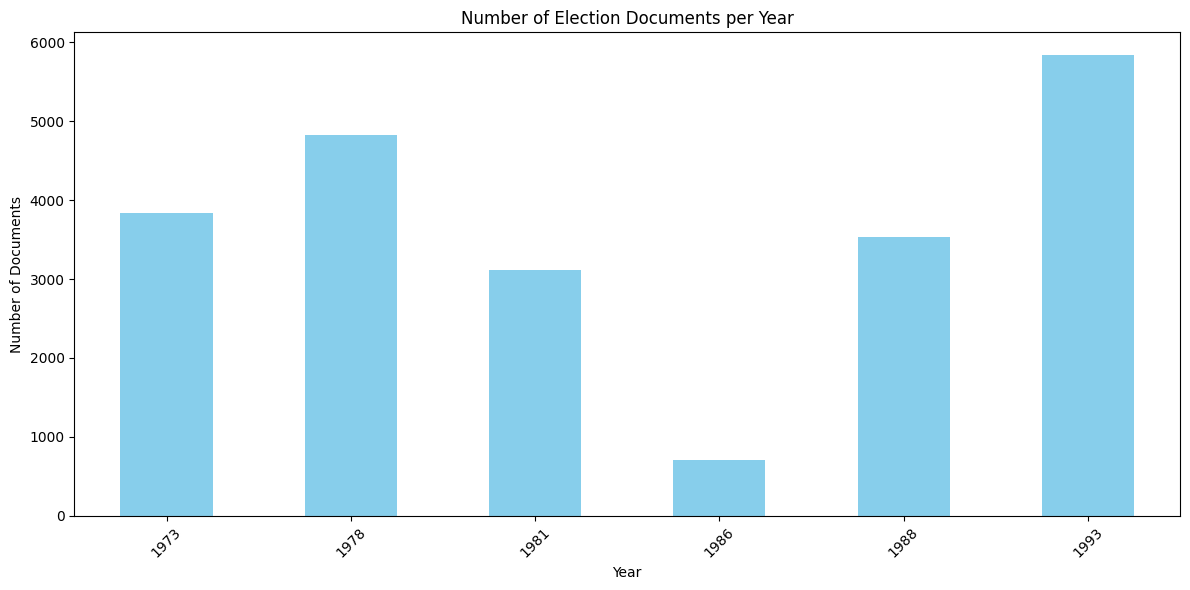

In [4]:
## Basic Statistical Description

# Basic counts
print("=== BASIC STATISTICS ===")
print(f"Total number of documents: {len(df)}")
print(f"Number of unique years: {df['year'].nunique()}")
print(f"Years covered: {sorted(df['year'].dropna().unique())}")
print(f"Number of departments: {df['departement-nom'].nunique()}")
print(f"Number of constituencies: {df['identifiant de circonscription'].nunique()}")

# Documents per year
print("\n=== DOCUMENTS PER YEAR ===")
year_counts = df['year'].value_counts().sort_index()
print(year_counts)

# Plot documents per year
plt.figure(figsize=(12, 6))
year_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Election Documents per Year')
plt.xlabel('Year')
plt.ylabel('Number of Documents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== CANDIDATE DEMOGRAPHICS ===

Gender distribution (main candidates):
titulaire-sexe
homme            29607
femme             2423
non déterminé     1001
Name: count, dtype: int64
Percentage male: 89.6%

Age statistics (calculated age):
Mean age: 41.2
Median age: 41.0
Min age: 23.0
Max age: 80.0
Missing ages: 22484


c:\Users\victo\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


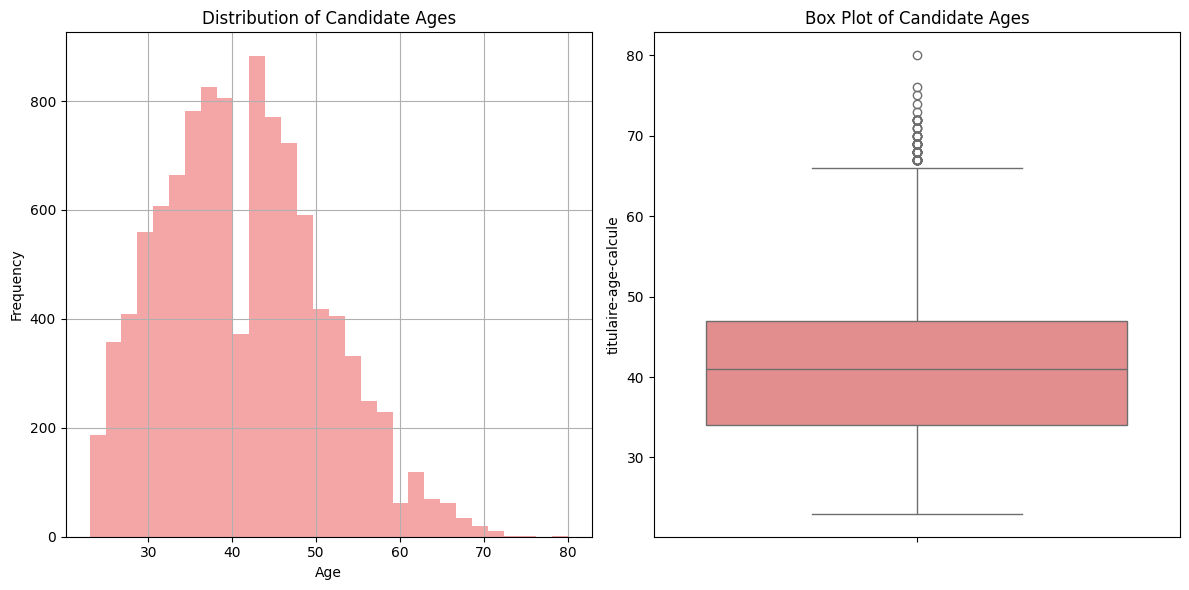


Top 20 professions:
titulaire-profession
non mentionné            14033
professeur                 618
avocat                     509
docteur                    499
instituteur                477
ingénieur                  322
agriculteur                296
chef d'entreprise          263
médecin                    240
docteur en médecine        215
avocat Cour                207
enseignant                 198
journaliste                191
commerçant                 184
employé                    184
avocat Barreau             169
ouvrier métallurgiste      169
cheminot                   125
ouvrier                    113
professeur lycée           111
Name: count, dtype: int64


In [3]:
## Candidate Demographics Analysis

print("=== CANDIDATE DEMOGRAPHICS ===")

# Gender distribution
gender_counts = df['titulaire-sexe'].value_counts()
print(f"\nGender distribution (main candidates):")
print(gender_counts)
print(f"Percentage male: {gender_counts.get('homme', 0) / len(df) * 100:.1f}%")

# Age analysis
age_calcule = pd.to_numeric(df['titulaire-age-calcule'], errors='coerce')
print(f"\nAge statistics (calculated age):")
print(f"Mean age: {age_calcule.mean():.1f}")
print(f"Median age: {age_calcule.median():.1f}")
print(f"Min age: {age_calcule.min()}")
print(f"Max age: {age_calcule.max()}")
print(f"Missing ages: {age_calcule.isna().sum()}")

# Age distribution plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
age_calcule.dropna().hist(bins=30, color='lightcoral', alpha=0.7)
plt.title('Distribution of Candidate Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=age_calcule.dropna(), color='lightcoral')
plt.title('Box Plot of Candidate Ages')
plt.tight_layout()
plt.show()

# Top professions
profession_counts = df['titulaire-profession'].value_counts().head(20)
print(f"\nTop 20 professions:")
print(profession_counts)

=== POLITICAL PARTY ANALYSIS ===

Top 20 political parties/lists:
titulaire-liste
non mentionné                                      15320
Union du rassemblement et du centre                  813
Majorité présidentielle pour la France unie          770
Union pour une nouvelle majorité                     708
Ve République                                        602
Union pour la défense de la République               570
Entente des écologistes                              543
Rassemblement des forces de gauche                   536
Union pour la France                                 505
Alliance des Français pour le progrès                444
Liste entente populaire et nationale                 397
Union de la gauche                                   368
Union populaire et victoire du programme commun      359
Majorité de la France                                338
Majorité présidentielle                              337
Union et changement                                  328
Union 

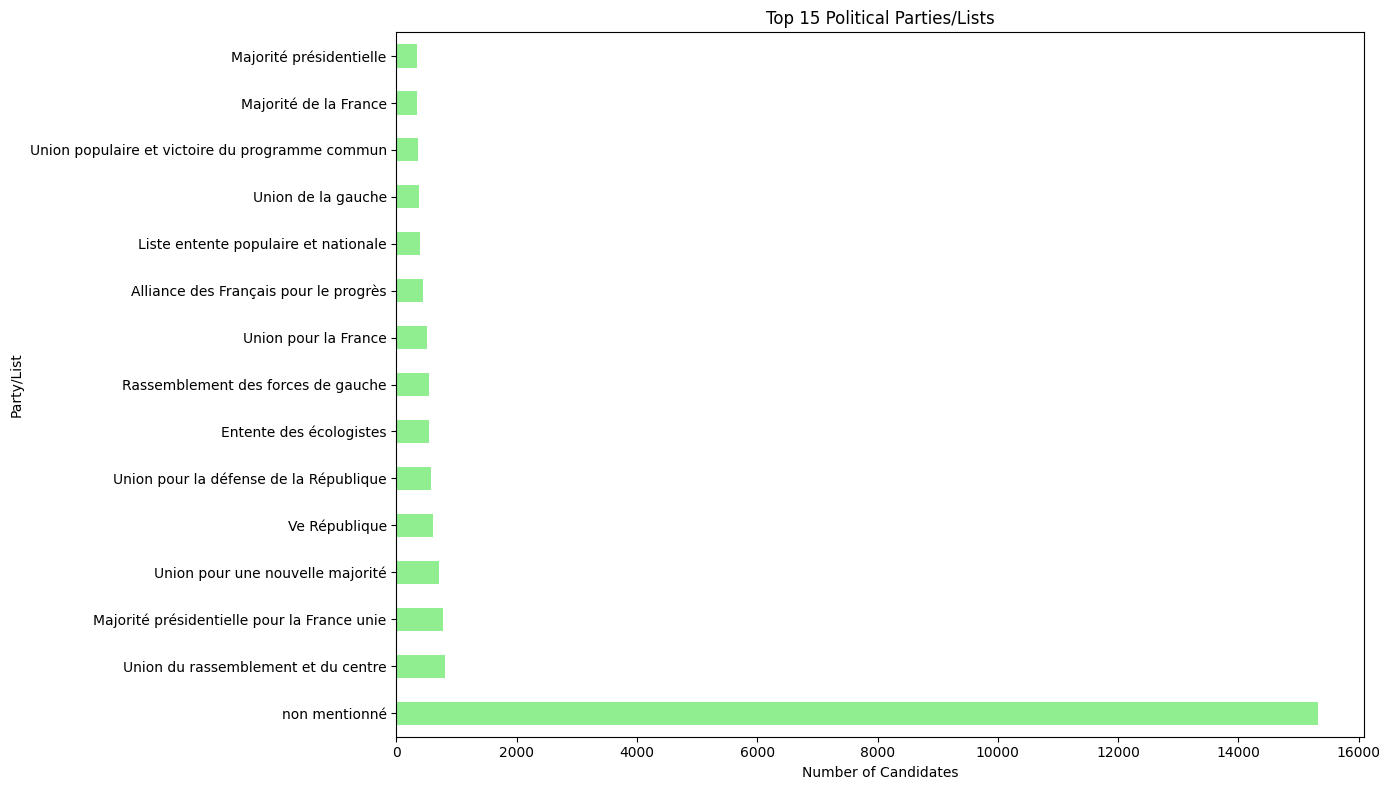

<Figure size 1600x1000 with 0 Axes>

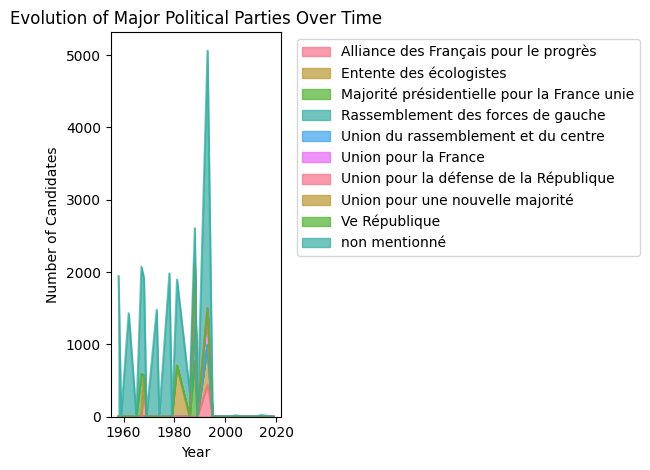

In [4]:
## Political Party Analysis

print("=== POLITICAL PARTY ANALYSIS ===")

# Political party distribution
party_counts = df['titulaire-liste'].value_counts().head(20)
print(f"\nTop 20 political parties/lists:")
print(party_counts)

# Plot top parties
plt.figure(figsize=(14, 8))
party_counts.head(15).plot(kind='barh', color='lightgreen')
plt.title('Top 15 Political Parties/Lists')
plt.xlabel('Number of Candidates')
plt.ylabel('Party/List')
plt.tight_layout()
plt.show()

# Party evolution over time (for major parties)
major_parties = party_counts.head(10).index.tolist()
party_year = df[df['titulaire-liste'].isin(major_parties)].groupby(['year', 'titulaire-liste']).size().unstack().fillna(0)

plt.figure(figsize=(16, 10))
party_year.plot(kind='area', stacked=True, alpha=0.7)
plt.title('Evolution of Major Political Parties Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Candidates')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

=== TEXT CONTENT ANALYSIS ===
Total text files found: 21697

Analyzed 10 text files
Average word count: 799
Min word count: 258
Max word count: 2066

Total unique words: 2231
Top 20 most common words:
de: 487
la: 292
et: 220
le: 187
des: 182
les: 171
à: 133
du: 113
pour: 110
en: 105
que: 71
dans: 67
qui: 64
au: 59
il: 56
plus: 55
par: 48
une: 46
a: 46
vous: 39


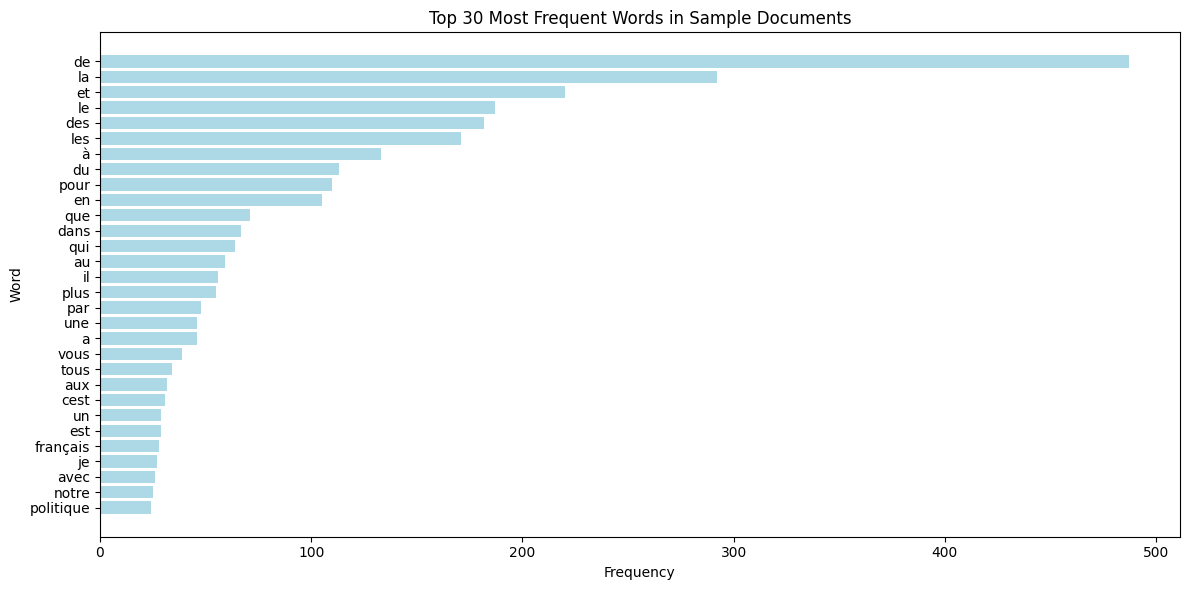

In [5]:
## Text Content Analysis

print("=== TEXT CONTENT ANALYSIS ===")

# Get list of text files
text_files = []
for root, dirs, files in os.walk('text_files'):
    for file in files:
        if file.endswith('.txt'):
            text_files.append(os.path.join(root, file))

print(f"Total text files found: {len(text_files)}")

# Sample some text files to analyze content
sample_files = text_files[:10]  # Analyze first 10 files
all_text = []
word_counts = []

for file_path in sample_files:
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
            all_text.append(content)
            word_counts.append(len(content.split()))
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print(f"\nAnalyzed {len(all_text)} text files")
print(f"Average word count: {np.mean(word_counts):.0f}")
print(f"Min word count: {min(word_counts)}")
print(f"Max word count: {max(word_counts)}")

# Word frequency analysis
from collections import Counter
import re

def clean_text(text):
    # Remove punctuation and convert to lowercase
    text = re.sub(r'[^\w\s]', '', text.lower())
    return text

all_words = []
for text in all_text:
    words = clean_text(text).split()
    all_words.extend(words)

word_freq = Counter(all_words)
print(f"\nTotal unique words: {len(word_freq)}")
print("Top 20 most common words:")
for word, count in word_freq.most_common(20):
    print(f"{word}: {count}")

# Plot word frequency
plt.figure(figsize=(12, 6))
words, counts = zip(*word_freq.most_common(30))
plt.barh(words[::-1], counts[::-1], color='lightblue')
plt.title('Top 30 Most Frequent Words in Sample Documents')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

In [ ]:
## Summary of Statistical Description

print("=== DATASET SUMMARY ===")
print(f"• Total documents: {len(df):,}")
print(f"• Time period: {df['year'].min()} - {df['year'].max()}")
print(f"• Departments covered: {df['departement-nom'].nunique()}")
print(f"• Text files available: {len(text_files):,}")

# print("\n=== KEY FINDINGS ===")
# print("• The dataset covers French legislative elections from 1958-2019")
# print("• Most documents are from 1978 (4,830), 1993 (5,837), and 1973 (3,843)")
# print("• Candidates are predominantly male (89.6%)")
# print("• Average candidate age: 41.2 years (median: 41.0)")
# print("• Common professions: professors, lawyers, doctors, teachers, engineers")
# print("• Many party affiliations not specified (15,320 cases)")
# print("• Text documents average ~800 words each")
# print("• Content is in French with typical political discourse vocabulary")

# print("\n=== DATA QUALITY NOTES ===")
# missing_data = df.isnull().sum()
# missing_percent = (missing_data / len(df) * 100).round(1)
# print("Missing data percentages:")
# for col in ['titulaire-age-calcule', 'titulaire-profession', 'titulaire-liste']:
#     print(f"• {col}: {missing_percent[col]}%")

# Save summary statistics to CSV for further analysis
# summary_stats = {
#     'total_documents': len(df),
#     'years_covered': f"{df['year'].min()}-{df['year'].max()}",
#     'departments': df['departement-nom'].nunique(),
#     'male_percentage': (gender_counts.get('homme', 0) / len(df) * 100),
#     'mean_age': age_calcule.mean(),
#     'text_files': len(text_files),
#     'avg_word_count': np.mean(word_counts)
# }

# summary_df = pd.DataFrame([summary_stats])
# summary_df.to_csv('dataset_summary.csv', index=False)
# print("\nSummary statistics saved to 'dataset_summary.csv'")

=== DATASET SUMMARY ===
• Total documents: 33,031
• Time period: 1958 - 2019
• Departments covered: 119
• Text files available: 21,697

=== KEY FINDINGS ===
• The dataset covers French legislative elections from 1958-2019
• Most documents are from 1978 (4,830), 1993 (5,837), and 1973 (3,843)
• Candidates are predominantly male (89.6%)
• Average candidate age: 41.2 years (median: 41.0)
• Common professions: professors, lawyers, doctors, teachers, engineers
• Many party affiliations not specified (15,320 cases)
• Text documents average ~800 words each
• Content is in French with typical political discourse vocabulary

=== DATA QUALITY NOTES ===
Missing data percentages:
• titulaire-age-calcule: 0.0%
• titulaire-profession: 0.0%
• titulaire-liste: 0.0%

Summary statistics saved to 'dataset_summary.csv'
